# 02 · Training Neural Networks: Optimisation and Regularisation

Backprop gives the gradient. This notebook covers everything else needed to train a network well: how to use the gradient (SGD, momentum, Adam, learning-rate schedules), the standard PyTorch training loop, and how to stop the network from memorising the training set (weight decay, dropout, augmentation, early stopping, normalisation).

**Contents**

1. Mini-batch stochastic gradient descent
2. Momentum
3. RMSProp and Adam
4. Learning-rate schedules
5. The PyTorch training loop
6. Reading learning curves
7. Regularisation: weight decay, dropout, data augmentation, early stopping
8. Normalisation layers
9. Gradient clipping and other practicalities

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch, torch.nn as nn
plt.rcParams.update({"figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})
rng = np.random.default_rng(0); torch.manual_seed(0)

## 1. Mini-batch stochastic gradient descent

The loss is an average over examples, $J(\boldsymbol{\theta}) = \frac1m\sum_{i=1}^m\ell^{(i)}(\boldsymbol{\theta})$, so its gradient is an average of per-example gradients. For large $m$ one exact gradient is expensive. Instead, at each step pick a random **mini-batch** $\mathcal{B}$ of size $B$ and use

$$
\mathbf{g} = \frac{1}{B}\sum_{i\in\mathcal{B}}\nabla_{\boldsymbol{\theta}}\ell^{(i)}(\boldsymbol{\theta}), \qquad \boldsymbol{\theta}\leftarrow\boldsymbol{\theta} - \alpha\,\mathbf{g}.
$$

**It is an unbiased estimate.** If the batch is drawn uniformly, each example appears with the same probability, so $\mathbb{E}[\mathbf{g}] = \frac1m\sum_i\nabla\ell^{(i)} = \nabla J$. On average we move in the right direction.

**Its noise shrinks with $B$.** For i.i.d. draws, $\mathrm{Cov}(\mathbf{g}) = \frac{1}{B}\mathrm{Cov}(\nabla\ell^{(i)})$, so the standard deviation falls like $1/\sqrt{B}$. Doubling the batch halves the variance but doubles the cost per step.

**Vocabulary.** One **iteration** = one mini-batch update. One **epoch** = one pass over the training set = $\lceil m/B\rceil$ iterations (shuffle each epoch).

| Batch size | Pros | Cons |
|---|---|---|
| $B = m$ (full batch) | exact gradient, smooth curve | very expensive per step, doesn't fit in memory |
| $B = 1$ (pure SGD) | cheapest step | very noisy, can't use vectorised hardware |
| $B = 32$–$512$ (mini-batch) | GPU-efficient, noise helps escape saddles/sharp minima | the usual choice |

Because of the noise, SGD with a constant $\alpha$ does not converge to a point but hovers around a minimum. Decaying $\alpha$ fixes this (section 4).

## 2. Momentum

Plain gradient descent zig-zags in long, narrow valleys (ill-conditioning, ML notes 01). **Momentum** keeps a running velocity:

$$
\mathbf{v}\leftarrow\beta\,\mathbf{v} + \mathbf{g}, \qquad \boldsymbol{\theta}\leftarrow\boldsymbol{\theta} - \alpha\,\mathbf{v}, \qquad \beta\approx 0.9 .
$$

Unrolling, $\mathbf{v}_t = \sum_{k\le t}\beta^{t-k}\mathbf{g}_k$ is an exponentially weighted sum of past gradients. Components that keep the same sign (the valley floor direction) add up, to about $\frac{1}{1-\beta} = 10\times$ for $\beta = 0.9$. Components that alternate sign (across the valley) cancel. Result: faster along the valley, less zig-zag.

## 3. RMSProp and Adam

**RMSProp** divides each parameter's step by a running root-mean-square of its gradient, so that every parameter moves at a similar rate regardless of its gradient scale:
$$
\mathbf{s}\leftarrow\beta_2\mathbf{s} + (1-\beta_2)\,\mathbf{g}\odot\mathbf{g}, \qquad \boldsymbol{\theta}\leftarrow\boldsymbol{\theta} - \alpha\,\frac{\mathbf{g}}{\sqrt{\mathbf{s}} + \varepsilon}.
$$

**Adam** = momentum (first moment) + RMSProp (second moment) + bias correction:
$$
\mathbf{m}_t = \beta_1\mathbf{m}_{t-1} + (1-\beta_1)\mathbf{g}_t, \quad
\mathbf{s}_t = \beta_2\mathbf{s}_{t-1} + (1-\beta_2)\mathbf{g}_t^2, \quad
\hat{\mathbf{m}}_t = \frac{\mathbf{m}_t}{1-\beta_1^t}, \quad
\hat{\mathbf{s}}_t = \frac{\mathbf{s}_t}{1-\beta_2^t}, \quad
\boldsymbol{\theta}_t = \boldsymbol{\theta}_{t-1} - \alpha\,\frac{\hat{\mathbf{m}}_t}{\sqrt{\hat{\mathbf{s}}_t} + \varepsilon}
$$
with defaults $\beta_1 = 0.9$, $\beta_2 = 0.999$, $\varepsilon = 10^{-8}$, $\alpha = 10^{-3}$.

**Why the bias correction?** Both averages start at 0, so early on they are biased towards 0. Unrolling with $\mathbf{m}_0 = 0$: $\mathbf{m}_t = (1-\beta_1)\sum_{k=1}^t\beta_1^{t-k}\mathbf{g}_k$. If the gradients have a constant mean $\mathbb{E}[\mathbf{g}]$, then $\mathbb{E}[\mathbf{m}_t] = (1-\beta_1)\frac{1-\beta_1^t}{1-\beta_1}\mathbb{E}[\mathbf{g}] = (1-\beta_1^t)\,\mathbb{E}[\mathbf{g}]$ (geometric series). Dividing by $1-\beta_1^t$ removes the bias. The same argument applies to $\mathbf{s}_t$.

**Properties.** The step size is roughly $\alpha$ per parameter whatever the gradient's scale, so Adam is robust to poor scaling and needs little tuning. It is the default for most deep-learning work (transformers in particular). SGD + momentum is still common for CNNs and sometimes generalises slightly better.

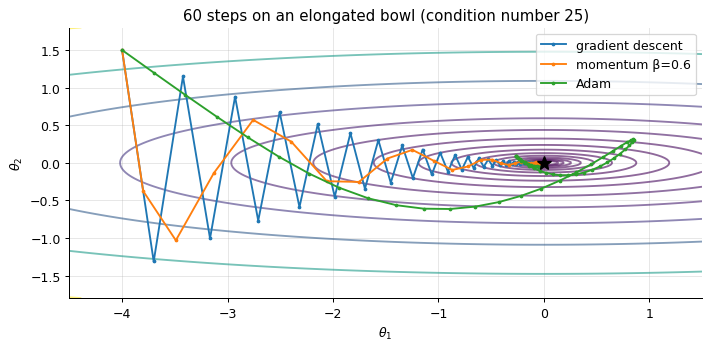

In [2]:
# Optimisers on an ill-conditioned quadratic J = 0.5*(a*t1^2 + b*t2^2)
a_, b_ = 1.0, 25.0
grad = lambda t: np.array([a_ * t[0], b_ * t[1]])
def run(step_fn, T=60):
    t, state, path = np.array([-4.0, 1.5]), {}, []
    for k in range(1, T + 1):
        path.append(t.copy()); t = step_fn(t, grad(t), state, k)
    return np.array(path)

def gd(t, g, s, k, lr=0.075): return t - lr * g
def momentum(t, g, s, k, lr=0.05, beta=0.6):
    s["v"] = beta * s.get("v", 0) + g; return t - lr * s["v"]
def adam(t, g, s, k, lr=0.3, b1=0.9, b2=0.999, eps=1e-8):
    s["m"] = b1 * s.get("m", 0) + (1 - b1) * g; s["s"] = b2 * s.get("s", 0) + (1 - b2) * g * g
    mh, sh = s["m"] / (1 - b1 ** k), s["s"] / (1 - b2 ** k); return t - lr * mh / (np.sqrt(sh) + eps)

T1, T2 = np.meshgrid(np.linspace(-4.5, 1.5, 200), np.linspace(-1.8, 1.8, 200))
plt.figure(figsize=(8, 4))
plt.contour(T1, T2, 0.5 * (a_ * T1 ** 2 + b_ * T2 ** 2), levels=np.logspace(-2, 1.7, 15), cmap="viridis", alpha=0.6)
for fn, name in [(gd, "gradient descent"), (momentum, "momentum β=0.6"), (adam, "Adam")]:
    p = run(fn); plt.plot(p[:, 0], p[:, 1], ".-", ms=4, label=name)
plt.plot(0, 0, "k*", ms=12); plt.legend(); plt.xlabel(r"$\theta_1$"); plt.ylabel(r"$\theta_2$")
plt.title("60 steps on an elongated bowl (condition number 25)"); plt.tight_layout(); plt.show()

Gradient descent zig-zags across the narrow direction and crawls along the long one. Momentum damps the zig-zag and reaches the minimum. Too much momentum (e.g. β = 0.9 on this small problem) overshoots and spirals, so α and β are tuned together. Adam rescales both directions to a similar step size, so it moves diagonally without zig-zagging; its momentum makes it overshoot a little before settling.

## 4. Learning-rate schedules

The learning rate is the most important hyperparameter. Too high → loss diverges or oscillates; too low → slow, may stall on plateaus. Common practice is to **start high and decay**:

- **Step decay**: multiply by 0.1 every $k$ epochs.
- **Cosine decay**: $\alpha_t = \alpha_{\min} + \frac12(\alpha_{\max} - \alpha_{\min})(1 + \cos(\pi t/T))$.
- **Warm-up**: increase linearly from ~0 for the first few hundred steps (important for Adam and transformers, whose early second-moment estimates are poor).
- **ReduceLROnPlateau**: halve $\alpha$ when the validation loss stops improving (used in the face labs).

In PyTorch: `torch.optim.lr_scheduler.*`, called with `scheduler.step()` once per epoch (or per step).

## 5. The PyTorch training loop

Running example: the scikit-learn **digits** dataset (1,797 greyscale 8×8 images, 10 classes). It is small enough to train in seconds on a CPU. We deliberately train on only 500 images so that overfitting is visible.

In [3]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader

digits = load_digits()
Xd = (digits.data / 16.0).astype(np.float32); yd = digits.target
X_tr, X_rest, y_tr, y_rest = train_test_split(Xd, yd, train_size=500, stratify=yd, random_state=0)
X_va, X_te, y_va, y_te = train_test_split(X_rest, y_rest, test_size=0.5, stratify=y_rest, random_state=0)
to_ds = lambda X, y: TensorDataset(torch.tensor(X), torch.tensor(y))
train_loader = DataLoader(to_ds(X_tr, y_tr), batch_size=32, shuffle=True)
val_loader = DataLoader(to_ds(X_va, y_va), batch_size=256)
print(f"train {len(y_tr)}, validation {len(y_va)}, test {len(y_te)}; input dim {Xd.shape[1]}, 10 classes")

train 500, validation 648, test 649; input dim 64, 10 classes


In [4]:
def make_mlp(p_drop=0.0):
    return nn.Sequential(nn.Linear(64, 256), nn.ReLU(), nn.Dropout(p_drop),
                         nn.Linear(256, 256), nn.ReLU(), nn.Dropout(p_drop),
                         nn.Linear(256, 10))                    # logits: CrossEntropyLoss applies log-softmax

def evaluate(model, loader, loss_fn):
    model.eval()                                   # dropout off, batch-norm uses running statistics
    total_loss, correct, n = 0.0, 0, 0
    with torch.no_grad():                          # no graph: faster, less memory
        for xb, yb in loader:
            out = model(xb)
            total_loss += loss_fn(out, yb).item() * len(yb)      # weight by batch size
            correct += (out.argmax(1) == yb).sum().item(); n += len(yb)
    return total_loss / n, correct / n

def train(model, optimizer, epochs=150, patience=None):
    loss_fn = nn.CrossEntropyLoss()
    hist = {"train_loss": [], "val_loss": [], "val_acc": []}
    best, best_state, wait = np.inf, None, 0
    for epoch in range(epochs):
        model.train()                              # dropout on
        run_loss, n = 0.0, 0
        for xb, yb in train_loader:
            optimizer.zero_grad()                  # 1. reset accumulated gradients
            loss = loss_fn(model(xb), yb)          # 2. forward pass + loss
            loss.backward()                        # 3. backprop
            optimizer.step()                       # 4. parameter update
            run_loss += loss.item() * len(yb); n += len(yb)
        vl, va = evaluate(model, val_loader, loss_fn)
        hist["train_loss"].append(run_loss / n); hist["val_loss"].append(vl); hist["val_acc"].append(va)
        if vl < best:                              # keep the best weights (checkpoint)
            best, wait = vl, 0; best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            wait += 1
            if patience is not None and wait >= patience:
                break                              # early stopping
    return hist, best_state

torch.manual_seed(0)
model = make_mlp()
hist_plain, _ = train(model, torch.optim.Adam(model.parameters(), lr=1e-3))
print(f"final: train loss {hist_plain['train_loss'][-1]:.4f}, val loss {hist_plain['val_loss'][-1]:.3f}, val acc {hist_plain['val_acc'][-1]:.3f}")

final: train loss 0.0003, val loss 0.221, val acc 0.957


**The five lines that every loop has**: `zero_grad()` → forward → loss → `backward()` → `step()`. Plus the two modes: `model.train()` for training and `model.eval()` + `torch.no_grad()` for evaluation. Frameworks like **PyTorch Lightning** (face lab) write this loop, the device handling, checkpointing and early stopping for you, but it is the same loop.

**Averaging metrics over an epoch.** Weight each batch by its size (the last batch is usually smaller). For non-linear metrics, don't average per-batch values: $\frac1B\sum_b\sqrt{\mathrm{MSE}_b} \le \sqrt{\frac1B\sum_b\mathrm{MSE}_b}$ by Jensen's inequality ($\sqrt{\cdot}$ is concave), so the average of per-batch RMSEs underestimates the true RMSE. Accumulate sums and take the root at the end.

## 6. Reading learning curves

| Pattern | Diagnosis | What to do |
|---|---|---|
| train and val loss both high, close together | **underfitting** (high bias) | bigger model, train longer, higher LR, better features |
| train loss ↓ to ~0, val loss ↓ then ↑ | **overfitting** (high variance) | regularise (below), more data/augmentation, early stopping |
| loss explodes / NaN | LR too high, exploding gradients | lower LR, gradient clipping, check data |
| loss flat from the start | LR too low, dead units, bug | LR range test, check init / gradients |

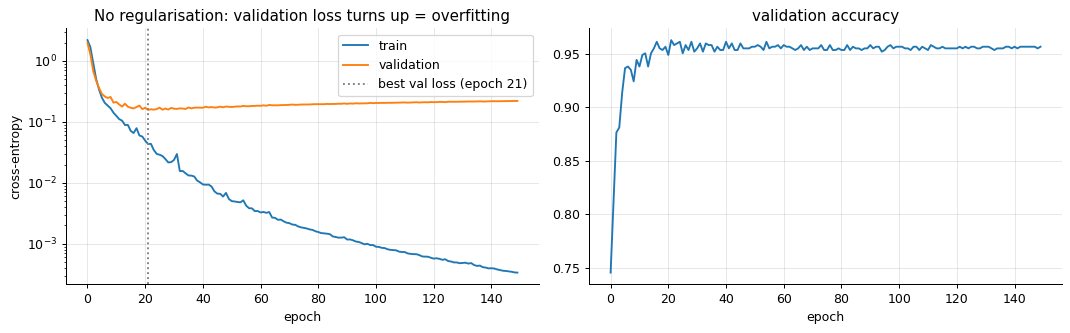

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
axes[0].plot(hist_plain["train_loss"], label="train"); axes[0].plot(hist_plain["val_loss"], label="validation")
best_ep = int(np.argmin(hist_plain["val_loss"]))
axes[0].axvline(best_ep, color="gray", ls=":", label=f"best val loss (epoch {best_ep})")
axes[0].set_yscale("log"); axes[0].set_xlabel("epoch"); axes[0].set_ylabel("cross-entropy"); axes[0].legend()
axes[0].set_title("No regularisation: validation loss turns up = overfitting")
axes[1].plot(hist_plain["val_acc"]); axes[1].set_xlabel("epoch"); axes[1].set_title("validation accuracy")
plt.tight_layout(); plt.show()

## 7. Regularisation

### 7.1 Weight decay (L2)

Add $\frac{\lambda}{2}\lVert\mathbf{W}\rVert^2$ to the loss (ML notes 03; biases usually excluded). Its gradient adds $\lambda\mathbf{W}$, so the SGD step becomes

$$
\mathbf{W}\leftarrow\mathbf{W} - \alpha(\nabla J + \lambda\mathbf{W}) = (1-\alpha\lambda)\,\mathbf{W} - \alpha\nabla J :
$$

shrink every weight by a constant factor, then take the data step. That is why L2 is called **weight decay**. With Adam the two are **not** equivalent: the $\lambda\mathbf{W}$ term would be divided by $\sqrt{\hat{\mathbf{s}}}$ like the rest of the gradient, so weights with large gradients get less decay. **AdamW** applies the decay directly, $\mathbf{W}\leftarrow\mathbf{W} - \alpha\lambda\mathbf{W}$, outside the adaptive step. Use `torch.optim.AdamW(..., weight_decay=λ)`.

### 7.2 Dropout

During training, each activation is independently set to 0 with probability $p$ and the survivors are scaled by $\frac{1}{1-p}$ (**inverted dropout**):
$$
\tilde{a}_j = \frac{r_j}{1-p}\,a_j, \qquad r_j\sim\mathrm{Bernoulli}(1-p).
$$
**Expectation is preserved:** $\mathbb{E}[\tilde a_j] = \frac{(1-p)}{1-p}a_j = a_j$. So at test time dropout is simply switched off (`model.eval()`) and no rescaling is needed.

Why it helps: a unit cannot rely on any particular other unit being present, so the network learns redundant, more robust features. It can also be seen as training an exponentially large **ensemble** of thinned sub-networks that share weights and averaging them at test time (compare bagging, ML notes 07). Typical $p$: 0.1–0.5.

### 7.3 Data augmentation

Apply random, label-preserving transformations to the training inputs each epoch (images: flips, crops, small rotations, colour jitter; audio: noise, time shift; text: harder). The model rarely sees the exact same input twice, which is like having more data. It also builds the desired **invariances** into the model. Only use transformations that don't change the label: a horizontal flip is fine for clothes, not for digits (a mirrored "2" is not a "2").

### 7.4 Early stopping

Monitor the validation loss, keep the best checkpoint, and stop after `patience` epochs without improvement. Training time acts as a regulariser: for a quadratic loss and small initial weights, early-stopped gradient descent behaves much like L2 regularisation.

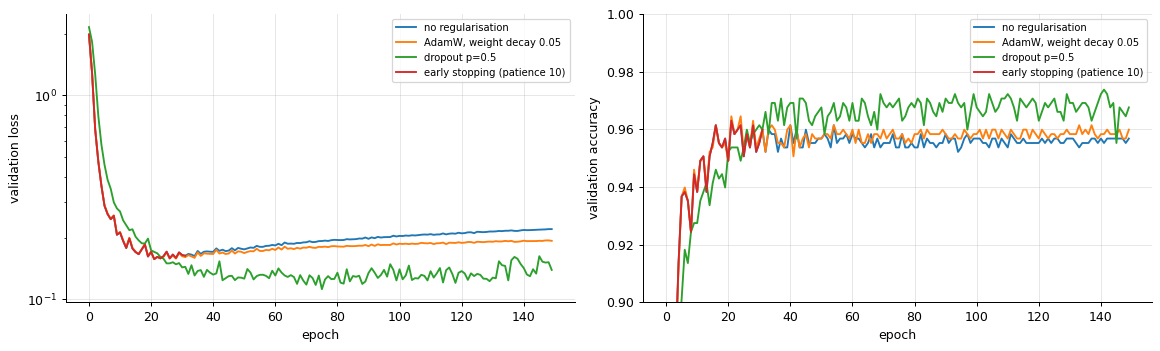

           no regularisation: test loss 0.153   test accuracy 0.972
                weight decay: test loss 0.136   test accuracy 0.971
                     dropout: test loss 0.118   test accuracy 0.974
  early stopping (best ckpt): test loss 0.116   test accuracy 0.969


In [6]:
results = {"no regularisation": hist_plain}
torch.manual_seed(0); m_wd = make_mlp()
results["AdamW, weight decay 0.05"], _ = train(m_wd, torch.optim.AdamW(m_wd.parameters(), lr=1e-3, weight_decay=0.05))
torch.manual_seed(0); m_do = make_mlp(p_drop=0.5)
results["dropout p=0.5"], _ = train(m_do, torch.optim.Adam(m_do.parameters(), lr=1e-3))
torch.manual_seed(0); m_es = make_mlp()
results["early stopping (patience 10)"], best_state = train(m_es, torch.optim.Adam(m_es.parameters(), lr=1e-3), patience=10)
m_es.load_state_dict(best_state)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for name, h in results.items():
    axes[0].plot(h["val_loss"], label=name); axes[1].plot(h["val_acc"], label=name)
axes[0].set_yscale("log"); axes[0].set_ylabel("validation loss"); axes[1].set_ylabel("validation accuracy")
for ax in axes: ax.set_xlabel("epoch"); ax.legend(fontsize=8)
axes[1].set_ylim(0.9, 1.0); plt.tight_layout(); plt.show()

test_loader = DataLoader(to_ds(X_te, y_te), batch_size=256)
for name, mdl in [("no regularisation", model), ("weight decay", m_wd), ("dropout", m_do), ("early stopping (best ckpt)", m_es)]:
    tl, ta = evaluate(mdl, test_loader, nn.CrossEntropyLoss())
    print(f"{name:>28}: test loss {tl:.3f}   test accuracy {ta:.3f}")

With only 500 training images, all three regularisers stop the validation loss from climbing, and they improve the test **loss**, but the test **accuracy** barely moves. The unregularised model mostly becomes *over-confident* rather than *wrong*: its argmax is still right, but its probabilities are too extreme. That is the same lesson as boosting in ML notes 07. On harder problems, or with less data, regularisation changes the accuracy as well.

## 8. Normalisation layers

**Batch normalisation** (Ioffe & Szegedy, 2015) standardises each unit's pre-activation over the mini-batch, then lets the network rescale it:
$$
\hat{z}_j = \frac{z_j - \mu_{\mathcal{B},j}}{\sqrt{\sigma^2_{\mathcal{B},j} + \varepsilon}}, \qquad \text{output} = \gamma_j\hat{z}_j + \beta_j
$$
with learnable $\gamma_j, \beta_j$. It keeps activations at a stable scale throughout training (the problem of section 6 in notebook 01), allowing higher learning rates and faster training, with a mild regularising effect (batch noise). **Train vs. eval**: in training it uses the batch statistics; at test time it uses running averages collected during training. This is another reason `model.eval()` matters.

**Layer normalisation** normalises over the features of each example instead of over the batch. It doesn't depend on the batch size and behaves the same in training and inference, which is why it is used in RNNs and transformers (notebook 05).

## 9. Gradient clipping and other practicalities

- **Gradient clipping**: if $\lVert\mathbf{g}\rVert > c$, rescale $\mathbf{g}\leftarrow c\,\mathbf{g}/\lVert\mathbf{g}\rVert$ (`torch.nn.utils.clip_grad_norm_(model.parameters(), c)`, between `backward()` and `step()`). It prevents a single huge gradient (RNNs, fine-tuning) from wrecking the weights.
- **Normalise the inputs** (standardise features, or scale pixels to [0,1] / ImageNet statistics for pre-trained models). Same reason as for linear models: conditioning.
- **Overfit a tiny batch first.** A correct model and training loop must reach ~0 loss on 10 examples. If it can't, there is a bug.
- **Seeds** (`torch.manual_seed`) for reproducibility; GPU operations may still be slightly non-deterministic.
- **Mixed precision** (float16/bfloat16) roughly halves memory and speeds up training on modern GPUs.

## Summary

- Mini-batch SGD uses an unbiased, noisy gradient estimate (variance $\propto 1/B$); an epoch is one pass over the data.
- Momentum averages gradients to damp zig-zags; Adam adds per-parameter scaling and bias correction and is the common default. Decay the learning rate (step, cosine, plateau), with warm-up for transformers.
- Training loop: `zero_grad` → forward → loss → `backward` → `step`; evaluate in `eval()` mode under `no_grad()`, weighting metrics by batch size.
- Diagnose with learning curves; fight overfitting with weight decay (AdamW), dropout (inverted, expectation-preserving), augmentation and early stopping with the best checkpoint.
- BatchNorm/LayerNorm stabilise activations; clip gradients when they can explode.